In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [17]:
from sklearn.cluster import KMeans


Part 1

Load the datasets using sklearn

In [18]:
#load_dataset
data=load_breast_cancer()


In [19]:
#convert it into Pandas dataframe
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [20]:
#Print datasets shape and first five rows
print(df.shape)
print(df.head())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

In [21]:

X=df.drop('target', axis=1)
y=df['target']

In [22]:
#split datasets into training and testing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
# apply feature scaling where required
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Answer
1 Scaling is required for knn but not necessary for decisiom tree because knn works on distances but decision tree is not working with distances so scaling is required in knn.
2
Logistic Regression
KNearest Neighbors
KMeans Clustering

Part 2 classification models implemenattaion


In [25]:
# model 1 Logistic Regression
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [26]:
y_pred_lr=lr.predict(X_test_scaled)

In [27]:
print("Accuracy Score=",accuracy_score(y_test,y_pred_lr))
print("Precision=",precision_score(y_test,y_pred_lr))
print("Recall Score=",recall_score(y_test,y_pred_lr))
print("F1 Score=",f1_score(y_test,y_pred_lr))
print("Confusion Matrix=",confusion_matrix(y_test,y_pred_lr))
print("Classification report=",classification_report(y_test,y_pred_lr))

Accuracy Score= 0.9736842105263158
Precision= 0.9722222222222222
Recall Score= 0.9859154929577465
F1 Score= 0.9790209790209791
Confusion Matrix= [[41  2]
 [ 1 70]]
Classification report=               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [28]:
#knn with 3 neighbors
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [29]:
knn_pred=knn.predict(X_test_scaled)

In [30]:
print("Accuracy Score=",accuracy_score(y_test,knn_pred))
print("Precision=",precision_score(y_test,knn_pred))
print("Recall Score=",recall_score(y_test,knn_pred))
print("F1 Score=",f1_score(y_test,knn_pred))
print("Confusion Matrix=",confusion_matrix(y_test,knn_pred))
print("Classification report=",classification_report(y_test,knn_pred))

Accuracy Score= 0.9473684210526315
Precision= 0.9577464788732394
Recall Score= 0.9577464788732394
F1 Score= 0.9577464788732394
Confusion Matrix= [[40  3]
 [ 3 68]]
Classification report=               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [31]:
#knn with 7 neighbors
knn1=KNeighborsClassifier(n_neighbors=7)
knn1.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=7)

In [32]:
knn1_pred=knn1.predict(X_test_scaled)

In [33]:
print("Accuracy Score=",accuracy_score(y_test,knn1_pred))
print("Precision=",precision_score(y_test,knn1_pred))
print("Recall Score=",recall_score(y_test,knn1_pred))
print("F1 Score=",f1_score(y_test,knn1_pred))
print("Confusion Matrix=",confusion_matrix(y_test,knn1_pred))
print("Classification report=",classification_report(y_test,knn1_pred))

Accuracy Score= 0.9473684210526315
Precision= 0.9577464788732394
Recall Score= 0.9577464788732394
F1 Score= 0.9577464788732394
Confusion Matrix= [[40  3]
 [ 3 68]]
Classification report=               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [34]:
# Decision tree
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [35]:
dt_pred=dt.predict(X_test)

In [36]:
print("Accuracy Score=",accuracy_score(y_test,dt_pred))
print("Precision=",precision_score(y_test,dt_pred))
print("Recall Score=",recall_score(y_test,dt_pred))
print("F1 Score=",f1_score(y_test,dt_pred))
print("Confusion Matrix=",confusion_matrix(y_test,dt_pred))
print("Classification report=",classification_report(y_test,dt_pred))

Accuracy Score= 0.9298245614035088
Precision= 0.9436619718309859
Recall Score= 0.9436619718309859
F1 Score= 0.9436619718309859
Confusion Matrix= [[39  4]
 [ 4 67]]
Classification report=               precision    recall  f1-score   support

           0       0.91      0.91      0.91        43
           1       0.94      0.94      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [39]:
#bagging classifier
bc=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,random_state=42)
bc.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50,
                  random_state=42)

In [40]:
bc_pred=bc.predict(X_test)

In [41]:
print("Accuracy Score=",accuracy_score(y_test,bc_pred))
print("Precision=",precision_score(y_test,bc_pred))
print("Recall Score=",recall_score(y_test,bc_pred))
print("F1 Score=",f1_score(y_test,bc_pred))
print("Confusion Matrix=",confusion_matrix(y_test,bc_pred))
print("Classification report=",classification_report(y_test,bc_pred))

Accuracy Score= 0.956140350877193
Precision= 0.9583333333333334
Recall Score= 0.971830985915493
F1 Score= 0.965034965034965
Confusion Matrix= [[40  3]
 [ 2 69]]
Classification report=               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [45]:
#Random Forest Classifier
RFC=RandomForestClassifier(n_estimators=100,random_state=42)
RFC.fit(X_train,y_train)


RandomForestClassifier(random_state=42)

In [46]:
rfc_pred=RFC.predict(X_test)

In [47]:
print("Accuracy Score=",accuracy_score(y_test,rfc_pred))
print("Precision=",precision_score(y_test,rfc_pred))
print("Recall Score=",recall_score(y_test,rfc_pred))
print("F1 Score=",f1_score(y_test,rfc_pred))
print("Confusion Matrix=",confusion_matrix(y_test,rfc_pred))
print("Classification report=",classification_report(y_test,rfc_pred))

Accuracy Score= 0.9649122807017544
Precision= 0.958904109589041
Recall Score= 0.9859154929577465
F1 Score= 0.9722222222222222
Confusion Matrix= [[40  3]
 [ 1 70]]
Classification report=               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [48]:
#gaussian Naive Bayes
gn=GaussianNB()
gn.fit(X_train,y_train)

GaussianNB()

In [49]:
gn_pred=gn.predict(X_test)

In [50]:
print("Accuracy Score=",accuracy_score(y_test,gn_pred))
print("Precision=",precision_score(y_test,gn_pred))
print("Recall Score=",recall_score(y_test,gn_pred))
print("F1 Score=",f1_score(y_test,gn_pred))
print("Confusion Matrix=",confusion_matrix(y_test,gn_pred))
print("Classification report=",classification_report(y_test,gn_pred))

Accuracy Score= 0.9736842105263158
Precision= 0.9594594594594594
Recall Score= 1.0
F1 Score= 0.9793103448275862
Confusion Matrix= [[40  3]
 [ 0 71]]
Classification report=               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Part 3 Comparison and Reasoning

In [53]:
models={
    "Logistic Regression":y_pred_lr,
    "KNN (k=3)":knn_pred,
    "knn (k=7)":knn1_pred,
    "Decision Tree":dt_pred,
    "Bagging Classifier":bc_pred,
    "Random Forest Classifier":rfc_pred,
    "Gaussian Naive Bayes":gn_pred
}

In [54]:
comparison=[]

for name,pred in models.items():
  comparison.append([
      name,
      accuracy_score(y_test,pred),
      precision_score(y_test,pred),
      recall_score(y_test,pred),
      f1_score(y_test,pred)
  ])

In [55]:
df_compare=pd.DataFrame(comparison,columns=['Model','Accuracy','Precision','Recall','F1 score'])


In [56]:
print(df_compare)

                      Model  Accuracy  Precision    Recall  F1 score
0       Logistic Regression  0.973684   0.972222  0.985915  0.979021
1                 KNN (k=3)  0.947368   0.957746  0.957746  0.957746
2                 knn (k=7)  0.947368   0.957746  0.957746  0.957746
3             Decision Tree  0.929825   0.943662  0.943662  0.943662
4        Bagging Classifier  0.956140   0.958333  0.971831  0.965035
5  Random Forest Classifier  0.964912   0.958904  0.985915  0.972222
6      Gaussian Naive Bayes  0.973684   0.959459  1.000000  0.979310


In [57]:
best_accuracy_model=df_compare.loc[df_compare['Accuracy'].idxmax()]
best_recall_model=df_compare.loc[df_compare['Recall'].idxmax()]
best_precision_model=df_compare.loc[df_compare['Precision'].idxmax()]

In [58]:
print("Best Accuracy Model=")
print(best_accuracy_model)

Best Accuracy Model=
Model        Logistic Regression
Accuracy                0.973684
Precision               0.972222
Recall                  0.985915
F1 score                0.979021
Name: 0, dtype: object


In [59]:
print("Best Recall Model=")
print(best_recall_model)

Best Recall Model=
Model        Gaussian Naive Bayes
Accuracy                 0.973684
Precision                0.959459
Recall                        1.0
F1 score                  0.97931
Name: 6, dtype: object


In [60]:
print("Best Precision Model=")
print(best_precision_model)


Best Precision Model=
Model        Logistic Regression
Accuracy                0.973684
Precision               0.972222
Recall                  0.985915
F1 score                0.979021
Name: 0, dtype: object


Answers
1 Random Forest outperform Decision Tree because it uses multiple decision tree and use random feature selection to introduce randomness in  the data but in decision tree it faces the proble of overfitting so random forest is better than single decision tree.
2 Naive Bayes assumes all features are independent given the class.

In real-world data (especially text, medical, finance, ML datasets), features are highly correlated

Example:

“fever” and “body pain” are clearly related

Naive Bayes treats them as totally independent → ❌ unrealistic

➡️ This wrong assumption leads to poor probability estimates.

3
Recall is important in medical dataset because it tells us how much positive actual labels are predicted accurately
4
knn is slower during prediction because it performs calculation at the time of prediction it does not require any pre requisite training



In [61]:
#Part 4
#KMeans Clustering
#scale data
X_scale=scaler.fit_transform(X)

In [63]:
wcss=[]
for k in range(1,10):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(X_scale)
  wcss.append(km.inertia_)


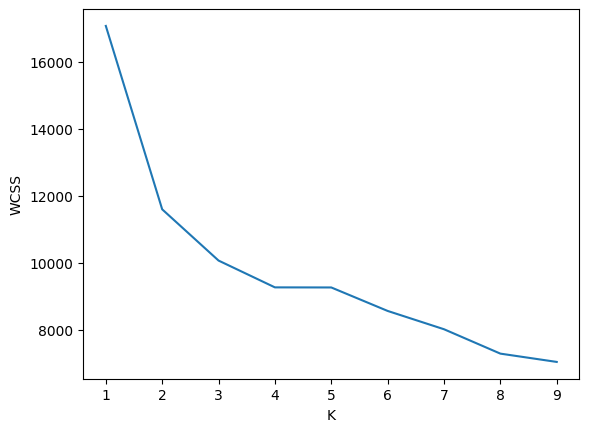

Cluster Labels: [0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1
 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 

In [64]:
plt.plot(range(1, 10), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# Train with optimal K (assume K=2)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scale)

print("Cluster Labels:", labels)
print("Cluster Centers:", kmeans.cluster_centers_)


#Answer
1
KMeans clustering is unsupervised learning algorithm because it does not use the class labels of the datasets .
2
Clustering is unsupervised

Clustering algorithms do not see labels

They group data based only on similarity / distance

Actual labels are based on ground-truth meaning, not distance

➡️ There is no guarantee clusters = labels.

2️⃣ Different objective functions

Clustering goal: minimize intra-cluster distance, maximize inter-cluster distance

Classification goal: predict true labels accurately